# 4교시 · 데이터 탐색과 정리
### — 요약한 숫자를 의심해 보기

앞 시간에 계속 **합계와 평균**을 냈습니다.
이번 시간에는 이렇게 묻습니다. **그 평균, 믿어도 됩니까?**

**이 시간이 끝나면 할 수 있는 것**

1. 평균과 중앙값이 왜 다른지 설명할 수 있다
2. 분포를 그려 보고 데이터의 모양을 확인할 수 있다
3. 표준편차가 무엇을 말해 주는지 안다
4. **이상치를 찾고, 지울지 남길지 스스로 판단할 수 있다**

### 오늘 쓰는 데이터 — 문구·가구 유통사 주문 내역

| | |
|---|---|
| **무엇** | 어느 문구·가구 유통사의 주문 내역 (Tableau 공식 샘플 데이터) |
| **기간** | 2023-01-03 ~ 2026-12-30 (4년치) |
| **크기** | 10,239행 × 21열 · 주문 5,111건 · 고객 804명 |
| **한 줄은** | 주문이 아니라 **주문에 담긴 품목 하나**입니다 |
| **지역** | 미국(10,038) · 캐나다(201) |

**주요 열**

| 열 | 뜻 |
|---|---|
| `Order ID` · `Order Date` · `Ship Date` | 주문번호 · 주문일 · 배송일 |
| `Customer ID` · `Segment` | 고객 · 고객 유형(Consumer / Corporate / Home Office) |
| `Region` · `State/Province` · `City` | 지역(Central / East / South / West) · 주 · 도시 |
| `Category` · `Sub-Category` · `Product Name` | 대분류(3종) · 소분류(17종) · 제품명 |
| `Sales` · `Quantity` · `Discount` · `Profit` | 매출 · 수량 · 할인율 · 이익 |

> **결측치·이상치·중복값이 일부러 들어 있습니다.**
> 실무에서 받는 데이터가 그렇기 때문입니다. 손대지 않은 원본이 필요하면
> `superstore_orders_raw.csv` 를 쓰세요.

In [1]:
import pandas as pd

BASE = 'https://raw.githubusercontent.com/JasonWhiteLee/ak-data-analysis-basics/main/'

orders = pd.read_csv(BASE + 'superstore_orders.csv', parse_dates=['Order Date', 'Ship Date'])
orders = orders.drop_duplicates()

print(orders.shape)

(10194, 21)


## 그래프에 한글이 나오게 하기

Colab 은 기본 상태에서 **한글을 네모(□□□)로 그립니다.** 폰트가 없기 때문입니다.
아래 두 셀을 먼저 실행하세요. 오늘 이후 그래프를 그릴 때마다 필요합니다.

In [2]:
!apt-get -qq install fonts-nanum > /dev/null

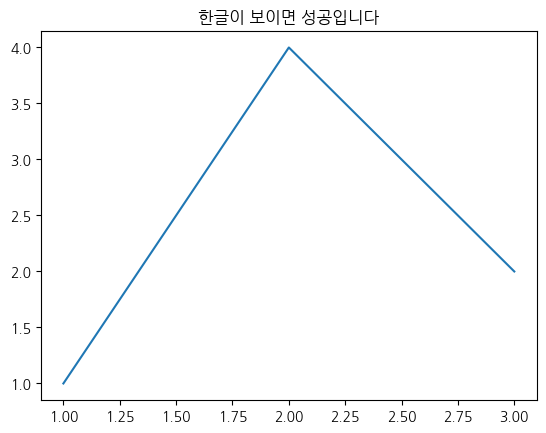

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)      # 마이너스 기호도 깨지므로 함께 설정

plt.plot([1, 2, 3], [1, 4, 2])
plt.title('한글이 보이면 성공입니다')
plt.show()

---
# 4-1. 평균 하나로 보고하면 생기는 일

주문 한 건당 매출이 얼마인지 보겠습니다.

In [4]:
round(orders['Sales'].mean(), 1)

np.float64(239.2)

**평균 주문 금액은 239.2 입니다.**

이 숫자를 보고 이런 생각이 듭니다 — "우리 고객은 보통 240 정도 쓰는구나."

**확인해 봅시다.** 정말 240 근처에 사람들이 몰려 있을까요?

In [6]:
print('평균 :', round(orders['Sales'].mean(), 1))
print('중앙값:', round(orders['Sales'].median(), 1))

평균 : 239.2
중앙값: 53.72


## 평균 239.2, 중앙값 53.7

**4배 넘게 차이납니다.**

- **평균** — 다 더해서 개수로 나눈 값
- **중앙값** — 크기순으로 줄 세웠을 때 **한가운데** 있는 값

중앙값이 53.7 이라는 건, **주문의 절반이 53.7 이하**라는 뜻입니다.
평균 239.2 는 대부분의 주문과 거리가 멉니다.

실제로 세어 봅시다.

In [ ]:
above_mean = (orders['Sales'] > orders['Sales'].mean())

print('평균보다 큰 주문: {:.1f}%'.format(above_mean.mean() * 100))
print('평균보다 작은 주문: {:.1f}%'.format((~above_mean).mean() * 100))

## 주문의 77%가 평균 이하입니다

"평균 주문금액 239" 라고 보고하면, 듣는 사람은 보통 그 정도 주문이 많다고 이해합니다.
**실제로는 열에 여덟이 그보다 적게 씁니다.**

왜 이렇게 됐을까요? 큰 주문 몇 개가 평균을 끌어올렸기 때문입니다.

In [ ]:
top1pct = orders['Sales'].nlargest(int(len(orders) * 0.01))

print('상위 1% 주문이 전체 매출에서 차지하는 비중: {:.1f}%'.format(
      top1pct.sum() / orders['Sales'].sum() * 100))

**상위 1% 주문(약 100건)이 전체 매출의 23%를 차지합니다.**

> ### 평균이 버리는 것
> 평균은 여러 값을 **하나로 줄인 숫자**입니다. 줄이는 과정에서 정보가 사라집니다.
> 사라진 정보는 **"값들이 어떻게 흩어져 있는가"** 입니다.
>
> 이 데이터처럼 한쪽에 몰려 있고 몇 개가 아주 큰 경우,
> 평균은 **어느 쪽도 대표하지 못합니다.**
> 다수의 작은 주문도 아니고, 소수의 큰 주문도 아닌 값이 됩니다.

## 그럼 무엇을 보고해야 할까요

| 상황 | 어울리는 값 |
|---|---|
| 값들이 고르게 퍼져 있다 | **평균** |
| 한쪽으로 치우쳐 있다 (소득, 매출, 방문수 등) | **중앙값** |
| 큰 값 자체가 중요하다 (총매출 예측) | **평균 또는 합계** |

**정답은 없습니다.** 다만 **하나만 보고하면 안 됩니다.**
평균과 중앙값이 크게 다르다면, 그 사실 자체가 알려야 할 정보입니다.

---
# 4-2. 분포 — 데이터의 모양을 직접 본다

숫자 두 개(평균·중앙값)로 짐작하는 대신, **그림으로 보면 한 번에 알 수 있습니다.**

**히스토그램**은 값의 구간별로 몇 개가 있는지 막대로 그린 그림입니다.

In [ ]:
orders['Sales'].plot(kind='hist', bins=50, figsize=(9, 4))
plt.title('주문 금액 분포')
plt.xlabel('주문 금액')
plt.show()

## 거의 아무것도 안 보입니다

맨 왼쪽에 막대 하나가 있고 나머지는 바닥에 붙어 있습니다.
**큰 값 몇 개 때문에 가로축이 10만까지 늘어나서** 대부분이 뭉개진 것입니다.

1,000 이하만 잘라서 다시 그려 봅시다.

In [ ]:
orders[orders['Sales'] < 1000]['Sales'].plot(kind='hist', bins=50, figsize=(9, 4))
plt.title('주문 금액 분포 (1,000 미만만)')
plt.xlabel('주문 금액')
plt.show()

## 이제 모양이 보입니다

**왼쪽에 몰려 있고 오른쪽으로 길게 꼬리를 끄는 모양**입니다.
이런 걸 "오른쪽으로 치우쳤다(우편향)"고 합니다.

매출, 소득, 방문 횟수, 체류 시간 — **업무에서 만나는 숫자는 대부분 이 모양입니다.**
그리고 이 모양에서는 **평균이 중앙값보다 항상 큽니다.**

> 앞에서 평균 239, 중앙값 53.7 이 나온 이유가 이 그림에 다 있습니다.
> **분포를 한 번 그려 봤다면 평균만 보고할 일이 없습니다.**

## 상자그림 — 한눈에 요약해서 보기

히스토그램이 분포의 모양을 보여 준다면, 상자그림은 **위치와 산포(퍼진 정도)** 를 요약해서 보여 줍니다.
여러 그룹을 나란히 비교할 때 특히 편합니다.

In [ ]:
orders[orders['Sales'] < 1000].boxplot(column='Sales', by='Segment', figsize=(9, 4))
plt.suptitle('')
plt.title('고객 유형별 주문 금액 (1,000 미만)')
plt.ylabel('주문 금액')
plt.show()

- **상자** = 가운데 50% (25% 지점 ~ 75% 지점)
- **상자 안의 선** = 중앙값
- **위아래 선(수염)** = 대략적인 범위
- **점** = 수염 밖으로 벗어난 값들

세 유형의 상자가 거의 같은 높이에 있습니다.
**고객 유형에 따른 차이가 별로 없어 보입니다.**

> 이게 "차이가 없다"는 뜻일까요, 아니면 "눈으로는 모르겠다"는 뜻일까요?
> **이 질문은 6교시에서 다시 다룹니다.**

---
# 4-3. 표준편차 — 얼마나 흩어져 있는가

평균이 "어디쯤인가"를 말한다면, **표준편차는 "얼마나 흩어져 있는가"** 를 말합니다.

같은 평균이라도 산포가 다르면 완전히 다른 데이터입니다.

In [ ]:
print('주문금액   평균 {:8.1f}   표준편차 {:8.1f}'.format(
      orders['Sales'].mean(), orders['Sales'].std()))

orders['ship_days'] = (orders['Ship Date'] - orders['Order Date']).dt.days

print('배송일수   평균 {:8.2f}   표준편차 {:8.2f}'.format(
      orders['ship_days'].mean(), orders['ship_days'].std()))

## 두 숫자를 비교해 보세요

| | 평균 | 표준편차 | 표준편차 ÷ 평균 |
|---|---|---|---|
| 주문 금액 | 239.2 | **1,209.2** | **5.1배** |
| 배송 일수 | 3.97 | 1.74 | 0.4배 |

**배송 일수는 평균 4일이고, 대부분 그 근처에 모여 있습니다.**
"보통 4일 걸립니다"라고 말해도 됩니다. 예측이 가능합니다.

**주문 금액은 평균이 239 인데 표준편차가 1,209 입니다.**
평균의 5배만큼 흩어져 있습니다. "보통 239 정도입니다"라고 말할 수 없습니다.

> ### 표준편차를 왜 찍는가
> **평균을 얼마나 믿어도 되는지 알려 주기 때문입니다.**
>
> 표준편차가 작으면 평균이 전체를 잘 대표합니다.
> 표준편차가 평균보다 크면, 그 평균은 대표값 노릇을 못 합니다.
>
> 그래서 평균을 보고할 때는 **표준편차를 함께 보는 것**이 기본입니다.

## 품목별로 보면 더 분명합니다

In [ ]:
by_subcat = orders.groupby('Sub-Category')['Sales'].agg(['mean', 'std', 'count']).round(1)
by_subcat['cv'] = (by_subcat['std'] / by_subcat['mean']).round(1)   # 표준편차 ÷ 평균

by_subcat.sort_values('cv', ascending=False).head(8)

맨 위를 보세요. **Fasteners 는 평균이 37인데 표준편차가 343 입니다.**
평균의 9배가 넘습니다. 클립이나 나사 같은 저가 소모품인데 산포가 이렇게 클 리가 없습니다.

**뭔가 이상합니다.** 다음 절에서 확인합니다.

---
# 4-4. 이상치 — 찾는 것보다 판단이 어렵다

**이상치**는 다른 값들과 유난히 동떨어진 값입니다.
찾는 방법은 간단한데, **어떻게 할지 정하는 게 어렵습니다.**

## 찾는 방법 — IQR

가운데 50% 범위(IQR)를 기준으로, 그 범위의 1.5배를 벗어나면 이상치로 봅니다.
상자그림의 "수염 밖 점"과 같은 기준입니다.

In [ ]:
Q1 = orders['Sales'].quantile(0.25)
Q3 = orders['Sales'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

print('Q1(25%): {:8.1f}'.format(Q1))
print('Q3(75%): {:8.1f}'.format(Q3))
print('상한    : {:8.1f}'.format(upper))
print()
print('이상치: {}건 ({:.1f}%)'.format((orders['Sales'] > upper).sum(),
                                   (orders['Sales'] > upper).mean() * 100))

## 1,183건이 이상치로 잡혔습니다. 전체의 11.6%입니다.

여기서 그냥 지우면 **매출의 상당 부분이 사라집니다.**
앞에서 봤듯이 상위 1%가 매출의 23%를 차지하고 있었죠.

> **IQR 은 "이상하다"를 판정해 주지 않습니다.**
> 그냥 "다른 값들에 비해 크다"를 계산해 줄 뿐입니다.
> 우편향 데이터에서는 정상적인 큰 주문도 전부 여기 걸립니다.
>
> **판단은 사람이 해야 합니다.**

## 큰 값들을 직접 들여다봅시다

In [ ]:
orders.nlargest(6, 'Sales')[['Order Date', 'Sub-Category', 'Sales', 'Quantity', 'Profit']]

## 두 종류가 섞여 있습니다

| | Sub-Category | Sales | Quantity | Profit | |
|---|---|---|---|---|---|
| 1 | Tables | **104,835** | 5 | **-69.9** | ??? |
| 2 | Machines | 22,638 | 6 | -1,811 | |
| 3 | Copiers | 17,500 | 5 | +8,400 | 정상 |
| 4 | Copiers | 14,000 | 4 | +6,720 | 정상 |

**3~4번은 이상하지 않습니다.** 복사기를 몇 대 샀고, 이익도 그만큼 났습니다.
금액이 클 뿐 **말이 되는 주문**입니다.

**1번은 이상합니다.**
- 테이블 5개에 104,835 — 한 개에 2만이 넘습니다
- 그런데 이익이 **-69.9** 입니다. 2만짜리 테이블을 팔았는데 손익이 70 남짓 마이너스?

**금액만 100배로 잘못 입력된 것**으로 보입니다.
숫자 하나가 아니라 **여러 열을 함께 봐야** 알 수 있었습니다.

## 반대쪽도 봅시다 — 작은 값

In [ ]:
print('Sales 가 0 인 주문:', (orders['Sales'] == 0).sum(), '건')
print('수량이 음수인 주문:', (orders['Quantity'] < 0).sum(), '건')

orders[orders['Quantity'] < 0][['Order Date', 'Sub-Category', 'Sales', 'Quantity']]

**매출이 0원인 주문**과 **수량이 음수인 주문**이 있습니다.

- 매출 0 — 사은품일 수도, 입력 누락일 수도 있습니다
- 수량 음수 — 반품 처리이거나 입력 오류입니다

2교시에서 본 온라인 소매 데이터에서는 **음수 수량이 취소를 뜻했습니다.**
같은 모양의 값이라도 **데이터마다 뜻이 다릅니다.**

> **"이 값이 왜 이렇게 생겼는지" 알아내기 전에는 지우면 안 됩니다.**
> 오류일 수도 있고, 우리가 모르는 업무 규칙일 수도 있습니다.

## 이상치를 어떻게 할 것인가 — 네 가지 선택지

| 선택 | 언제 | 이 데이터에서 |
|---|---|---|
| **고친다** | 원래 값을 알 수 있을 때 | 104,835 -> 1,048.35 (100으로 나눔) |
| **뺀다** | 명백한 오류이고 원래 값을 모를 때 | 매출 0, 수량 음수 |
| **남긴다** | 진짜로 일어난 일일 때 | 복사기 대량 주문 |
| **따로 본다** | 그 자체가 관심사일 때 | "대형 거래만 분석" |

**어느 쪽을 골랐든 보고서에 적어야 합니다.**
2교시에서 봤듯이, 무엇을 뺐는지 안 적으면 나중에 숫자가 어긋나도 원인을 찾을 수 없습니다.

In [ ]:
# 명백한 오류만 걸러낸 표를 만들어 봅니다
clean = orders[(orders['Sales'] > 0) & (orders['Quantity'] > 0)].copy()

# 자릿수 오류로 보이는 건은 고쳐서 씁니다
clean.loc[clean['Sales'] > 50000, 'Sales'] = clean['Sales'] / 100

print('원본  : {:>6}행   평균 {:8.1f}   최대 {:9.0f}'.format(
      len(orders), orders['Sales'].mean(), orders['Sales'].max()))
print('정리본: {:>6}행   평균 {:8.1f}   최대 {:9.0f}'.format(
      len(clean), clean['Sales'].mean(), clean['Sales'].max()))

> 24건을 처리했을 뿐인데 평균이 눈에 띄게 바뀝니다.
> **이상치는 개수가 적어도 평균을 크게 흔듭니다.** 중앙값은 거의 안 움직입니다.

In [ ]:
print('중앙값  원본 {:.1f}  ->  정리본 {:.1f}'.format(
      orders['Sales'].median(), clean['Sales'].median()))

---
# 4-5. 실습 — 이익(Profit)을 같은 방식으로 살펴보기

매출에 했던 것을 **이익에 그대로** 해 봅니다.
**한 셀씩 빈칸을 채우고 실행**하세요.

### ① 이익의 평균을 구하세요

In [ ]:
print('평균: {:8.2f}'.format(orders['Profit'].mean()))

### ② 이익의 중앙값을 구하세요 — 평균과 얼마나 다릅니까

In [ ]:
print('중앙값: {:8.2f}'.format(orders['Profit'].median()))

### ③ 이익의 표준편차를 구하세요

In [ ]:
print('표준편차: {:8.2f}'.format(orders['Profit'].std()))

### ④ 적자 주문이 몇 %인지 구하세요

In [ ]:
print('적자 비율: {:.1f}%'.format((orders['Profit'] < 0).mean() * 100))

### ⑤ 이익 분포를 히스토그램으로 그리세요 (-500 ~ 500 만)

In [ ]:
orders[orders['Profit'].between(-500, 500)]['Profit'].plot(
    kind='hist', bins=60, figsize=(9, 3))
plt.title('주문별 이익 분포')
plt.axvline(0, color='red', linewidth=1)
plt.show()

### ⑥ 가장 손해가 큰 주문 5건을 보세요

In [ ]:
orders.nsmallest(5, 'Profit')[
    ['Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']]

---
# 정리 — 오늘 쓴 것

## 코드

| 하는 일 | 코드 |
|---|---|
| 평균 / 중앙값 | `df['열'].mean()` · `.median()` |
| 표준편차 | `df['열'].std()` |
| 사분위수 | `df['열'].quantile(0.25)` |
| 전체 요약 | `df['열'].describe()` |
| 히스토그램 | `df['열'].plot(kind='hist', bins=50)` |
| 상자그림 | `df.boxplot(column='값', by='그룹')` |
| 가장 큰 / 작은 N개 | `df.nlargest(5, '열')` · `df.nsmallest(5, '열')` |
| 한글 폰트 | `!apt-get -qq install fonts-nanum` + `plt.rc('font', family='NanumGothic')` |

## 남길 것 세 가지

1. **평균과 중앙값을 함께 본다** — 크게 다르면 그 자체가 알려야 할 정보입니다
2. **표준편차는 평균을 얼마나 믿어도 되는지 알려 준다** — 평균보다 크면 대표값 노릇을 못 합니다
3. **이상치는 찾는 것보다 판단이 어렵다** — 오류인지 진짜 사건인지는 여러 열을 함께 봐야 압니다

---

### 다음 시간

지금까지 확인한 것을 **남에게 보여 주는 방법**을 다룹니다.
그리고 이런 것을 하게 됩니다 — **같은 데이터로 정반대 인상을 주는 그래프 두 개 만들기.**

---
# 자주 쓰는 패턴

숫자 하나를 보고 끝내지 않으려면 **늘 짝으로** 봅니다.

| 하고 싶은 것 | 패턴 |
|---|---|
| 가운데 값 | `df['열'].mean()` · `df['열'].median()` — **둘을 함께** |
| 퍼진 정도 | `df['열'].std()` |
| 사분위수 | `df['열'].quantile(0.25)` · `.quantile(0.75)` |
| 한 번에 요약 | `df['열'].describe()` |
| 큰/작은 N개 | `df.nlargest(5, '열')` · `df.nsmallest(5, '열')` |
| 분포 그리기 | `df['열'].plot(kind='hist', bins=50)` |
| 그룹별 분포 | `df.boxplot(column='값', by='그룹')` |
| 비율 구하기 | `(df['열'] < 0).mean() * 100` |

아래에서 **평균·중앙값 짝 패턴을 열만 바꿔** 여러 번 써 봅니다.

### 패턴 — ① 매출의 평균과 중앙값

In [ ]:
print('평균  :', round(orders['Sales'].mean(), 1))
print('중앙값:', round(orders['Sales'].median(), 1))

### 같은 패턴 — ② 이익

In [ ]:
print('평균  :', round(orders['Profit'].mean(), 1))
print('중앙값:', round(orders['Profit'].median(), 1))

### 같은 패턴 — ③ 수량

In [ ]:
print('평균  :', round(orders['Quantity'].mean(), 2))
print('중앙값:', round(orders['Quantity'].median(), 2))

### 패턴 `df.nlargest(N, '열')` — ① 매출 상위 3건

In [ ]:
orders.nlargest(3, 'Sales')[['Sub-Category', 'Sales']]

### 같은 패턴 — ② 이익 하위 3건

In [ ]:
orders.nsmallest(3, 'Profit')[['Sub-Category', 'Profit']]

---
# 연습문제

지금까지 배운 것으로 직접 풀어 봅니다. **빈칸(`____`)을 채우고 실행**하세요.
막히면 위로 올라가 같은 함수를 쓴 곳을 찾아보거나, 맨 끝 정리표를 보세요.

> 답이 하나만 있는 건 아닙니다. **실행해서 원하는 결과가 나오면 맞은 것입니다.**

### 문제 1. 이익(`Profit`)의 평균을 출력하세요.

In [ ]:
print('평균  :', round(orders['Profit'].mean(), 2))

### 문제 2. 이익의 중앙값을 출력하세요.

In [ ]:
print('중앙값:', round(orders['Profit'].median(), 2))

### 문제 3. 이익의 표준편차를 출력하세요.

In [ ]:
print('표준편차:', round(orders['Profit'].std(), 2))

### 문제 4. `Quantity` 의 25% 지점과 75% 지점을 구하세요.

In [ ]:
print('Q1:', orders['Quantity'].quantile(0.25))
print('Q3:', orders['Quantity'].quantile(0.75))

### 문제 5. 이익이 가장 큰 3건을 보세요.

In [ ]:
orders.nlargest(3, 'Profit')[['Sub-Category', 'Sales', 'Profit']]

### 문제 6. 이익이 가장 작은(가장 손해 본) 3건을 보세요.

In [ ]:
orders.nsmallest(3, 'Profit')[['Sub-Category', 'Sales', 'Discount', 'Profit']]

### 문제 7. 할인율(`Discount`) 분포를 히스토그램으로 그리세요.

In [ ]:
orders['Discount'].plot(kind='hist', bins=20, figsize=(8, 3))
plt.title('할인율 분포')
plt.show()

### 문제 8. `Segment` 별 이익을 상자그림으로 비교하세요. (-500 ~ 500 만)

In [ ]:
orders[orders['Profit'].between(-500, 500)].boxplot(
    column='Profit', by='Segment', figsize=(8, 3))
plt.suptitle('')
plt.show()